In [2]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
import jax.scipy.special as jss
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
rng = jr.key(8)
num_entries = 600
num_fourier_entries = 900
total_length = 1000
dx = total_length/(num_entries - 1)
fourier_length = dx*(num_fourier_entries - 1)


normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
#normalization_factor = 1
linspace = dx*jnp.arange(num_entries)
num_fft_samples = 10

freq_spacing = (fourier_length) / num_fourier_entries
freqs = jnp.fft.fftfreq(num_fourier_entries, d=freq_spacing)
omegas = 2 * jnp.pi * freqs


variance = 1.0
scale = 2*fourier_length
nu = 50

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale, lognu = inference_params
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


def matern_magnitude(omega, variance, scale, nu):
    inference_params = (jnp.log(variance), jnp.log(scale), jnp.log(nu))
    return jnp.sqrt(general_matern_spectral_density(omega, inference_params))

raw_average_amplitude_data = matern_magnitude(omegas, variance, scale, nu)

def fft_field_hartley(noise):
    size = noise.shape[0]
    H = noise * raw_average_amplitude_data         
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_entries]

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fold_spectrum(X):
    N = X.shape[0]
    m = N // 2 + 1
    full_fold = ((X + jnp.roll(X[::-1], 1)) / 2)[:m]
    return full_fold[1:]

def get_spectrum(field):
    spectra_with_noise = hartley(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(spectra_with_noise**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept


def get_spectrum2(field):
    spectra_with_noise = jnp.fft.fft(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(jnp.abs(spectra_with_noise)**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept

Text(0.5, 1.0, 'Spectral Density with discrete points at omegas')

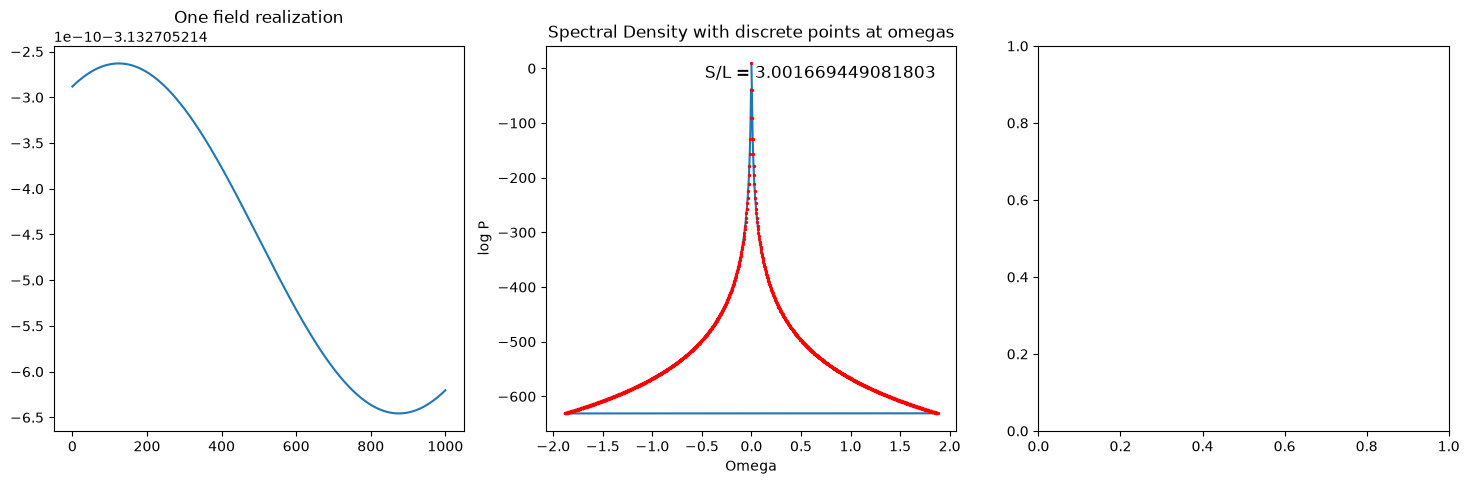

In [3]:
rng = jr.PRNGKey(0)
rng, k1, k2, k3, k4 = jr.split(rng, 5)
xi = jr.normal(k1, shape = (num_fourier_entries,))
field = fft_field_hartley(xi)

fig, axes = plt.subplots(1, 3, figsize = (18, 5))
axes[0].plot(linspace, field)
axes[0].set_title("One field realization")
axes[1].plot(omegas, jnp.log(general_matern_spectral_density(omegas, (jnp.log(variance), jnp.log(scale), jnp.log(nu)))))
axes[1].scatter(omegas, jnp.log(general_matern_spectral_density(omegas, (jnp.log(variance), jnp.log(scale), jnp.log(nu)))), color="red", s=2, zorder = 2)
axes[1].set_xlabel("Omega")
axes[1].set_ylabel("log P")
axes[1].text(x=0.95, y=0.95, s=f"S/L = {scale/total_length}", 
             transform=axes[1].transAxes, 
             fontsize=12, ha='right', va='top')
axes[1].set_title("Spectral Density with discrete points at omegas")

Text(0.5, 1.0, 'Spectral Density at omega = 0 with scale = 3001.669449081803 variance = 1.0')

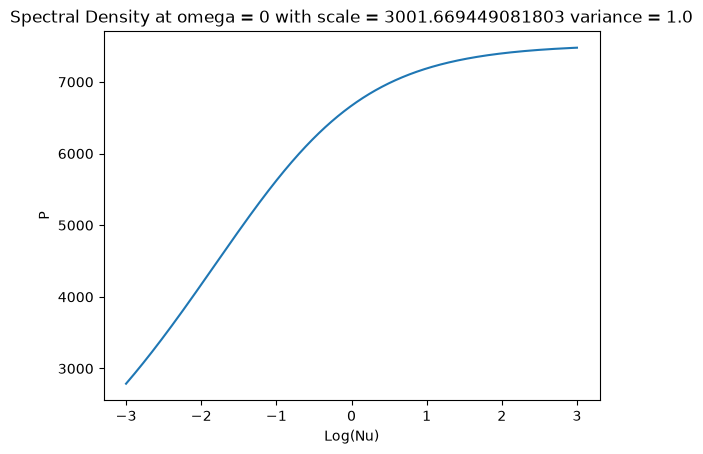

In [4]:
lognus = jnp.linspace(-3, 3, 1000)
vmapped_func = jax.vmap(general_matern_spectral_density, in_axes=(None, (None, None, 0)))

# Assume 'omega' is a specific frequency you want to evaluate at
densities = vmapped_func(0, (jnp.log(variance), jnp.log(scale), lognus))
plt.plot(lognus, densities)
plt.xlabel("Log(Nu)")
plt.ylabel("P")
plt.title(f"Spectral Density at omega = 0 with scale = {scale} variance = {variance}")

Filename: samples_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  SAMPLES       1 ImageHDU        21   (786432, 516, 12)   float32   
  2  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  3  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  4  INTEGRATED INNER 68.8 PC    1 ImageHDU        18   (786432, 12)   float32   


Filename: ../mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   


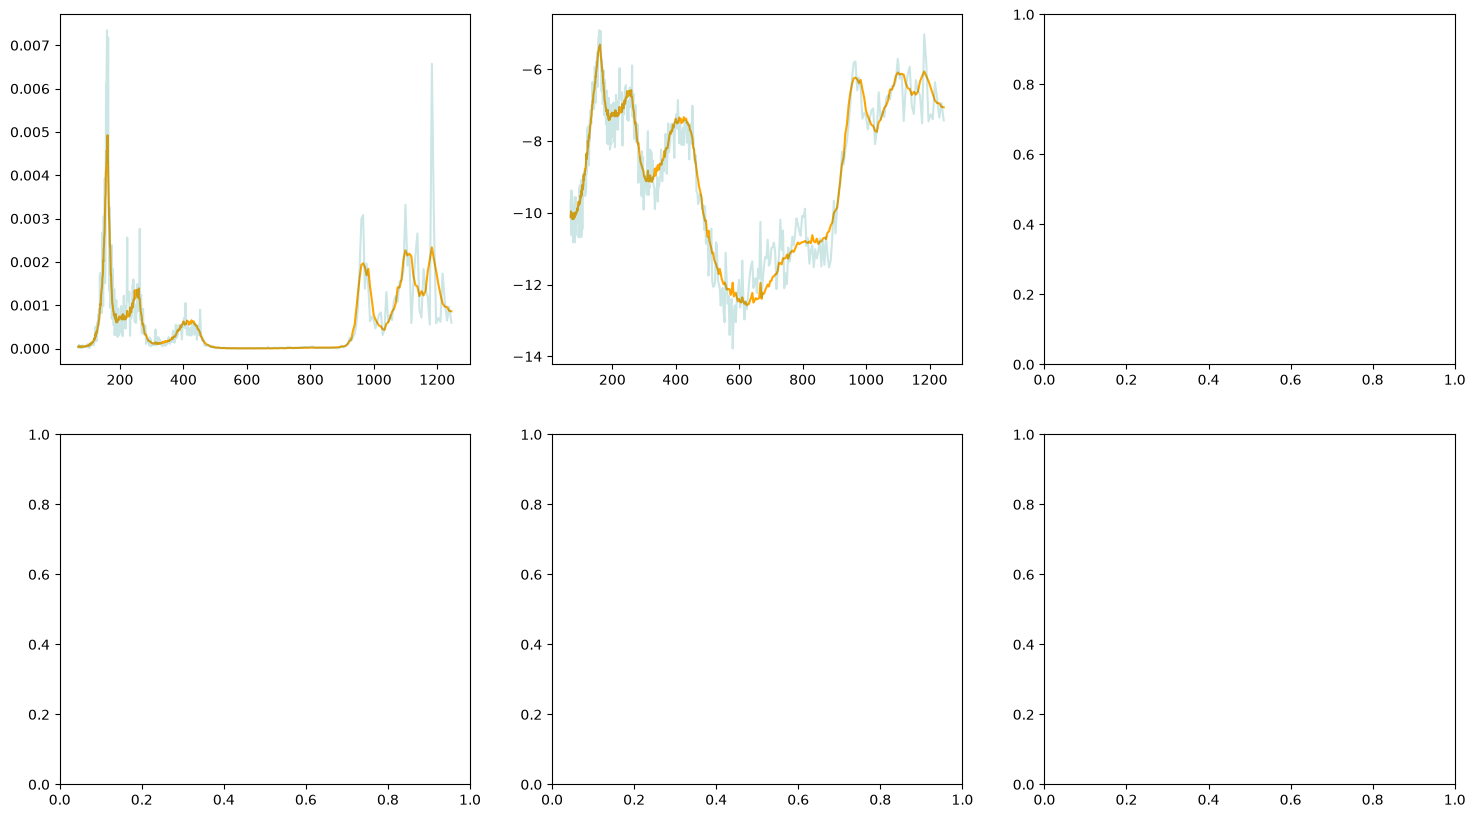

In [5]:
with fits.open("samples_healpix.fits") as hdul:
    hdul.info()
    pix = hp.pixelfunc.ang2pix(256, theta=0.0, phi=0.0, nest=True, lonlat=True)
    samples_gc = hdul["SAMPLES"].data[:, :, pix]          
    radii = hdul["radial pixel centers"].data["radial pixel centers"]  

with fits.open("../mean_and_std_healpix.fits") as hdul:
    hdul.info()
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_dust_data_along_galactic_center = hdul["MEAN"].data[:, galactic_center_healpix]
    std_dust_data_along_galactic_center = hdul["STD."].data[:, galactic_center_healpix]
    healpix_size = hdul["MEAN"].data[0, :].size
    data_x = hdul['RADIAL PIXEL CENTERS'].data.field(0)
    distance_boundaries = hdul['RADIAL PIXEL BOUNDARIES'].data.field(0)
    distance_gaps = np.diff(distance_boundaries)
    integrated_dust = np.dot(distance_gaps, hdul["MEAN"].data)


samples_gc = jnp.asarray(np.ascontiguousarray(samples_gc).astype(np.float32))
log_samples = jnp.log(samples_gc)
radii = jnp.asarray(np.ascontiguousarray(radii).astype(np.float32))

fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes[0][0].plot(radii, mean_dust_data_along_galactic_center, color = "orange")
axes[0][1].plot(radii, np.log(mean_dust_data_along_galactic_center), color = "orange")
for i in range (0, 1):
    axes[0][0].plot(radii, samples_gc[i, :], color = "teal", alpha = 0.2)
    axes[0][1].plot(radii, log_samples[i, :], color = "teal", alpha = 0.2)



